# PeMS 传感器变化追踪分析 (2025年)

## 分析目标

从车道级别分析交通系统，追踪每次元数据更新时的变化：

1. **新增传感器**：新出现的传感器ID
2. **移除传感器**：消失的传感器ID
3. **元数据变化**：同一传感器的属性变化（车道数、位置、类型等）

## 修正说明

- 第一个时间段：新增/移除均为 0（没有参照基准）
- 后续时间段：相对于上一个时间段计算变化

## 1. 环境配置

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("库加载完成！")

库加载完成！


In [2]:
# 配置路径
META_FOLDER = "../d03_meta"  # 元数据文件夹路径
OUTPUT_DIR = "../output/sensor_tracking"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 时间范围
START_DATE = datetime(2024, 11, 1)
END_DATE = datetime(2025, 12, 31)

print(f"元数据文件夹: {META_FOLDER}")
print(f"输出目录: {OUTPUT_DIR}")
print(f"时间范围: {START_DATE.date()} ~ {END_DATE.date()}")

元数据文件夹: ../d03_meta
输出目录: ../output/sensor_tracking
时间范围: 2024-11-01 ~ 2025-12-31


## 2. 数据加载函数

In [3]:
def parse_date_from_filename(filename):
    """
    从文件名解析日期
    例如：d03_text_meta_2025_01_18.txt -> datetime(2025, 1, 18)
    """
    match = re.search(r'(\d{4})_(\d{2})_(\d{2})', os.path.basename(filename))
    if match:
        return datetime(int(match.group(1)), int(match.group(2)), int(match.group(3)))
    return None


def load_metadata(file_path):
    """
    加载元数据文件，返回完整的 DataFrame
    """
    columns = [
        'ID', 'Fwy', 'Dir', 'District', 'County', 'City', 
        'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length',
        'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2', 
        'User_ID_3', 'User_ID_4'
    ]
    
    df = pd.read_csv(
        file_path, 
        sep='\t', 
        names=columns,
        header=0,
        dtype={
            'ID': str,
            'Fwy': str,
            'Dir': str,
            'District': str,
            'County': str,
            'City': str,
            'Type': str,
            'Name': str
        }
    )
    
    return df


print("函数定义完成！")

函数定义完成！


In [4]:
# 扫描并加载所有元数据文件
all_files = sorted(glob.glob(os.path.join(META_FOLDER, "d*_text_meta_*.txt")))

# 筛选指定时间范围
files_in_range = []
for f in all_files:
    date = parse_date_from_filename(f)
    if date and START_DATE <= date <= END_DATE:
        files_in_range.append((f, date))

# 按日期排序
files_in_range.sort(key=lambda x: x[1])

print(f"找到 {len(files_in_range)} 个元数据文件")
print(f"时间范围: {files_in_range[0][1].date()} ~ {files_in_range[-1][1].date()}")
print(f"\n前5个文件:")
for f, d in files_in_range[:5]:
    print(f"  {d.date()}: {os.path.basename(f)}")

找到 36 个元数据文件
时间范围: 2024-11-27 ~ 2025-12-30

前5个文件:
  2024-11-27: d03_text_meta_2024_11_27.txt
  2025-01-18: d03_text_meta_2025_01_18.txt
  2025-01-30: d03_text_meta_2025_01_30.txt
  2025-02-04: d03_text_meta_2025_02_04.txt
  2025-02-06: d03_text_meta_2025_02_06.txt


## 3. 传感器变化检测

In [5]:
# 需要追踪变化的关键字段
KEY_FIELDS = ['Fwy', 'Dir', 'Abs_PM', 'Latitude', 'Longitude', 'Type', 'Lanes', 'Length']

def compare_sensor_metadata(df_prev, df_curr):
    """
    比较两个时间点的传感器元数据
    
    返回:
    - added_ids: 新增的传感器ID集合
    - removed_ids: 移除的传感器ID集合
    - changed_sensors: 元数据发生变化的传感器列表
    """
    prev_ids = set(df_prev['ID'].dropna())
    curr_ids = set(df_curr['ID'].dropna())
    
    # 新增和移除
    added_ids = curr_ids - prev_ids
    removed_ids = prev_ids - curr_ids
    common_ids = prev_ids & curr_ids
    
    # 检测元数据变化（针对共同存在的传感器）
    changed_sensors = []
    
    if len(common_ids) > 0:
        # 建立索引
        prev_indexed = df_prev.set_index('ID')
        curr_indexed = df_curr.set_index('ID')
        
        for sensor_id in common_ids:
            prev_row = prev_indexed.loc[sensor_id]
            curr_row = curr_indexed.loc[sensor_id]
            
            # 检查每个关键字段
            changes = {}
            for field in KEY_FIELDS:
                prev_val = prev_row.get(field)
                curr_val = curr_row.get(field)
                
                # 处理 NaN
                prev_is_nan = pd.isna(prev_val)
                curr_is_nan = pd.isna(curr_val)
                
                if prev_is_nan and curr_is_nan:
                    continue
                elif prev_is_nan != curr_is_nan:
                    changes[field] = {'from': prev_val, 'to': curr_val}
                elif prev_val != curr_val:
                    # 数值型字段：检查是否有显著差异
                    if field in ['Abs_PM', 'Latitude', 'Longitude', 'Length']:
                        try:
                            if abs(float(prev_val) - float(curr_val)) > 1e-6:
                                changes[field] = {'from': prev_val, 'to': curr_val}
                        except:
                            changes[field] = {'from': prev_val, 'to': curr_val}
                    else:
                        changes[field] = {'from': prev_val, 'to': curr_val}
            
            if changes:
                changed_sensors.append({
                    'ID': sensor_id,
                    'changes': changes,
                    'changed_fields': list(changes.keys())
                })
    
    return added_ids, removed_ids, changed_sensors


print("比较函数定义完成！")
print(f"追踪的关键字段: {KEY_FIELDS}")

比较函数定义完成！
追踪的关键字段: ['Fwy', 'Dir', 'Abs_PM', 'Latitude', 'Longitude', 'Type', 'Lanes', 'Length']


In [6]:
# 执行变化追踪
print("开始追踪传感器变化...")
print("=" * 60)

all_changes = []  # 汇总统计
all_added_details = []  # 新增传感器详情
all_removed_details = []  # 移除传感器详情
all_metadata_changes = []  # 元数据变化详情

prev_df = None
prev_date = None

for i, (file_path, date) in enumerate(files_in_range):
    curr_df = load_metadata(file_path)
    
    if prev_df is None:
        # 第一个时间点：没有参照基准，新增/移除均为 0
        record = {
            'Date': date,
            'Date_Str': date.strftime('%Y-%m-%d'),
            'Total': len(curr_df),
            'Added': 0,
            'Removed': 0,
            'Metadata_Changed': 0,
            'Net_Change': 0,
            'Is_First': True
        }
        print(f"[{date.date()}] 初始状态: {len(curr_df)} 个传感器")
    else:
        # 比较变化
        added_ids, removed_ids, changed_sensors = compare_sensor_metadata(prev_df, curr_df)
        
        record = {
            'Date': date,
            'Date_Str': date.strftime('%Y-%m-%d'),
            'Total': len(curr_df),
            'Added': len(added_ids),
            'Removed': len(removed_ids),
            'Metadata_Changed': len(changed_sensors),
            'Net_Change': len(added_ids) - len(removed_ids),
            'Is_First': False
        }
        
        # 记录详情
        for sensor_id in added_ids:
            sensor_info = curr_df[curr_df['ID'] == sensor_id].iloc[0]
            all_added_details.append({
                'Date': date,
                'ID': sensor_id,
                'Fwy': sensor_info.get('Fwy'),
                'Dir': sensor_info.get('Dir'),
                'Type': sensor_info.get('Type'),
                'Lanes': sensor_info.get('Lanes'),
                'Abs_PM': sensor_info.get('Abs_PM'),
                'Name': sensor_info.get('Name')
            })
        
        for sensor_id in removed_ids:
            sensor_info = prev_df[prev_df['ID'] == sensor_id].iloc[0]
            all_removed_details.append({
                'Date': date,
                'ID': sensor_id,
                'Fwy': sensor_info.get('Fwy'),
                'Dir': sensor_info.get('Dir'),
                'Type': sensor_info.get('Type'),
                'Lanes': sensor_info.get('Lanes'),
                'Abs_PM': sensor_info.get('Abs_PM'),
                'Name': sensor_info.get('Name')
            })
        
        for change in changed_sensors:
            all_metadata_changes.append({
                'Date': date,
                'ID': change['ID'],
                'Changed_Fields': ', '.join(change['changed_fields']),
                'Details': str(change['changes'])
            })
        
        # 打印有变化的时间点
        if len(added_ids) > 0 or len(removed_ids) > 0 or len(changed_sensors) > 0:
            print(f"[{date.date()}] 总数: {len(curr_df)} | "
                  f"+{len(added_ids)} -{len(removed_ids)} | "
                  f"元数据变化: {len(changed_sensors)}")
    
    all_changes.append(record)
    prev_df = curr_df
    prev_date = date

print("=" * 60)
print(f"追踪完成！共 {len(all_changes)} 个时间点")

开始追踪传感器变化...
[2024-11-27] 初始状态: 1859 个传感器
[2025-01-18] 总数: 1873 | +14 -0 | 元数据变化: 10
[2025-01-30] 总数: 1874 | +1 -0 | 元数据变化: 1
[2025-02-04] 总数: 1876 | +2 -0 | 元数据变化: 0
[2025-02-06] 总数: 1886 | +12 -2 | 元数据变化: 24
[2025-02-08] 总数: 1887 | +1 -0 | 元数据变化: 5
[2025-02-13] 总数: 1889 | +2 -0 | 元数据变化: 4
[2025-03-01] 总数: 1888 | +0 -1 | 元数据变化: 7
[2025-07-26] 总数: 1890 | +10 -8 | 元数据变化: 18
[2025-07-29] 总数: 1890 | +0 -0 | 元数据变化: 2
[2025-08-01] 总数: 1889 | +0 -1 | 元数据变化: 2
[2025-08-07] 总数: 1890 | +1 -0 | 元数据变化: 3
[2025-08-14] 总数: 1890 | +2 -2 | 元数据变化: 4
[2025-08-16] 总数: 1888 | +0 -2 | 元数据变化: 0
[2025-08-19] 总数: 1890 | +2 -0 | 元数据变化: 1
[2025-08-22] 总数: 1887 | +0 -3 | 元数据变化: 2
[2025-08-28] 总数: 1886 | +1 -2 | 元数据变化: 3
[2025-09-26] 总数: 1890 | +4 -0 | 元数据变化: 6
[2025-10-07] 总数: 1891 | +1 -0 | 元数据变化: 0
[2025-10-09] 总数: 1893 | +2 -0 | 元数据变化: 3
[2025-10-15] 总数: 1892 | +0 -1 | 元数据变化: 3
[2025-11-25] 总数: 1892 | +6 -6 | 元数据变化: 10
[2025-12-02] 总数: 1886 | +0 -6 | 元数据变化: 1
[2025-12-12] 总数: 1892 | +7 -1 | 元数据变化: 6
[2025-12

In [7]:
# 转换为 DataFrame
changes_df = pd.DataFrame(all_changes)
added_df = pd.DataFrame(all_added_details) if all_added_details else pd.DataFrame()
removed_df = pd.DataFrame(all_removed_details) if all_removed_details else pd.DataFrame()
metadata_changes_df = pd.DataFrame(all_metadata_changes) if all_metadata_changes else pd.DataFrame()

print("数据汇总:")
print(f"  时间点数: {len(changes_df)}")
print(f"  新增记录数: {len(added_df)}")
print(f"  移除记录数: {len(removed_df)}")
print(f"  元数据变化记录数: {len(metadata_changes_df)}")

数据汇总:
  时间点数: 36
  新增记录数: 85
  移除记录数: 41
  元数据变化记录数: 136


## 4. 变化统计汇总

In [8]:
# 显示变化记录
print("传感器变化记录:")
display(changes_df[['Date_Str', 'Total', 'Added', 'Removed', 'Metadata_Changed', 'Net_Change']])

传感器变化记录:


,Date_Str,Total,Added,Removed,Metadata_Changed,Net_Change
0,2024-11-27,1859,0,0,0,0
1,2025-01-18,1873,14,0,10,14
2,2025-01-30,1874,1,0,1,1
3,2025-02-04,1876,2,0,0,2
4,2025-02-06,1886,12,2,24,10
5,2025-02-08,1887,1,0,5,1
6,2025-02-13,1889,2,0,4,2
7,2025-03-01,1888,0,1,7,-1
8,2025-03-18,1888,0,0,0,0
9,2025-04-08,1888,0,0,0,0


In [9]:
# 统计摘要（排除第一个时间点）
changes_after_first = changes_df[~changes_df['Is_First']]

print("=" * 60)
print("统计摘要")
print("=" * 60)
print(f"初始传感器数: {changes_df.iloc[0]['Total']}")
print(f"最终传感器数: {changes_df.iloc[-1]['Total']}")
print(f"净变化: {changes_df.iloc[-1]['Total'] - changes_df.iloc[0]['Total']}")
print()
print(f"总新增次数: {changes_after_first['Added'].sum()}")
print(f"总移除次数: {changes_after_first['Removed'].sum()}")
print(f"总元数据变化次数: {changes_after_first['Metadata_Changed'].sum()}")
print()
print(f"有变化的时间点数: {((changes_after_first['Added'] > 0) | (changes_after_first['Removed'] > 0) | (changes_after_first['Metadata_Changed'] > 0)).sum()}")
print(f"无变化的时间点数: {((changes_after_first['Added'] == 0) & (changes_after_first['Removed'] == 0) & (changes_after_first['Metadata_Changed'] == 0)).sum()}")

统计摘要
初始传感器数: 1859
最终传感器数: 1903
净变化: 44

总新增次数: 85
总移除次数: 41
总元数据变化次数: 136

有变化的时间点数: 26
无变化的时间点数: 9


## 5. 新增传感器详情

In [10]:
if len(added_df) > 0:
    print(f"新增传感器详情 (共 {len(added_df)} 条记录):")
    display(added_df.head(20))
    
    # 按类型统计
    print("\n按类型统计新增传感器:")
    print(added_df['Type'].value_counts())
    
    # 按高速公路统计
    print("\n按高速公路统计新增传感器:")
    print(added_df['Fwy'].value_counts().head(10))
else:
    print("没有新增传感器记录")

新增传感器详情 (共 85 条记录):


,Date,ID,Fwy,Dir,Type,Lanes,Abs_PM,Name
0,2025-01-18,319645,50,E,OR,2,10.926,SB Watt Ave
1,2025-01-18,3422057,20,E,FR,1,185.186,Uren St to 20EB OFF
2,2025-01-18,3422052,20,E,ML,2,185.113,20EB JEO Uren St ML
3,2025-01-18,3422053,20,W,OR,1,185.196,49SB to 20WB Slip
4,2025-01-18,3422051,20,E,ML,1,185.322,20EB JWO Uren St ML
5,2025-01-18,3422054,20,E,OR,1,185.232,Uren St to 20EB Slip
6,2025-01-18,3020091,50,E,HV,1,10.926,SB Watt Ave
7,2025-01-18,3043012,5,S,HV,1,508.020,JNO Laguna Blvd
8,2025-01-18,3422055,20,E,OR,1,185.067,Uren St to 20EB Slip
9,2025-01-18,3422058,20,W,FR,2,185.267,20WB to 49WB OFF



按类型统计新增传感器:
Type
ML    37
OR    21
FR    15
HV    12
Name: count, dtype: int64

按高速公路统计新增传感器:
Fwy
80     22
5      20
50     11
20      9
99      8
162     7
12      5
89      2
193     1
Name: count, dtype: int64


## 6. 移除传感器详情

In [11]:
if len(removed_df) > 0:
    print(f"移除传感器详情 (共 {len(removed_df)} 条记录):")
    display(removed_df.head(20))
    
    # 按类型统计
    print("\n按类型统计移除传感器:")
    print(removed_df['Type'].value_counts())
    
    # 按高速公路统计
    print("\n按高速公路统计移除传感器:")
    print(removed_df['Fwy'].value_counts().head(10))
else:
    print("没有移除传感器记录")

移除传感器详情 (共 41 条记录):


,Date,ID,Fwy,Dir,Type,Lanes,Abs_PM,Name
0,2025-02-06,3021071,80,W,FR,1,102.054,80WB TO Riverside
1,2025-02-06,316454,80,W,FR,2,103.508,WB Douglas Blvd
2,2025-03-01,314821,5,N,ML,5,519.478,Jibboom St
3,2025-07-26,313560,80,W,ML,4,99.421,Weigh Station
4,2025-07-26,315890,80,W,HV,1,99.421,Weigh Station
5,2025-07-26,316773,80,E,ML,3,73.437,E. of Pole Line Rd
6,2025-07-26,312139,50,E,ML,5,4.722,16th St
7,2025-07-26,312141,50,E,OR,2,4.722,16th St
8,2025-07-26,312901,51,S,OR,1,6.725,Fulton Ave to 51SB Slip
9,2025-07-26,318493,50,W,ML,5,10.252,16th St



按类型统计移除传感器:
Type
ML    23
FR     8
OR     6
HV     4
Name: count, dtype: int64

按高速公路统计移除传感器:
Fwy
80     9
50     8
5      7
162    7
89     4
99     3
51     2
12     1
Name: count, dtype: int64


## 7. 元数据变化详情

In [12]:
if len(metadata_changes_df) > 0:
    print(f"元数据变化详情 (共 {len(metadata_changes_df)} 条记录):")
    display(metadata_changes_df.head(20))
    
    # 按变化字段统计
    print("\n各字段变化频次:")
    all_changed_fields = []
    for fields in metadata_changes_df['Changed_Fields']:
        all_changed_fields.extend(fields.split(', '))
    print(pd.Series(all_changed_fields).value_counts())
else:
    print("没有元数据变化记录")

元数据变化详情 (共 136 条记录):


,Date,ID,Changed_Fields,Details
0,2025-01-18,313938,Length,"{'Length': {'from': 0.82, 'to': 0.753}}"
1,2025-01-18,317815,"Dir, Abs_PM, Longitude, Length","{'Dir': {'from': 'N', 'to': 'S'}, 'Abs_PM': {'..."
2,2025-01-18,319630,Length,"{'Length': {'from': 2.71, 'to': 0.277}}"
3,2025-01-18,3422041,Length,"{'Length': {'from': 3.13, 'to': 1.29}}"
4,2025-01-18,319631,Length,"{'Length': {'from': 0.656, 'to': 0.277}}"
5,2025-01-18,315061,Length,"{'Length': {'from': 1.943, 'to': 0.892}}"
6,2025-01-18,317814,Length,"{'Length': {'from': 1.031, 'to': 1.303}}"
7,2025-01-18,319805,Length,"{'Length': {'from': 1.37, 'to': 1.102}}"
8,2025-01-18,3053011,Length,"{'Length': {'from': 1.379, 'to': 1.097}}"
9,2025-01-18,315060,Length,"{'Length': {'from': 1.946, 'to': 0.916}}"



各字段变化频次:
Length       114
Abs_PM        25
Longitude     25
Latitude      23
Lanes         15
Dir            2
Type           2
Fwy            1
Name: count, dtype: int64


## 8. 可视化

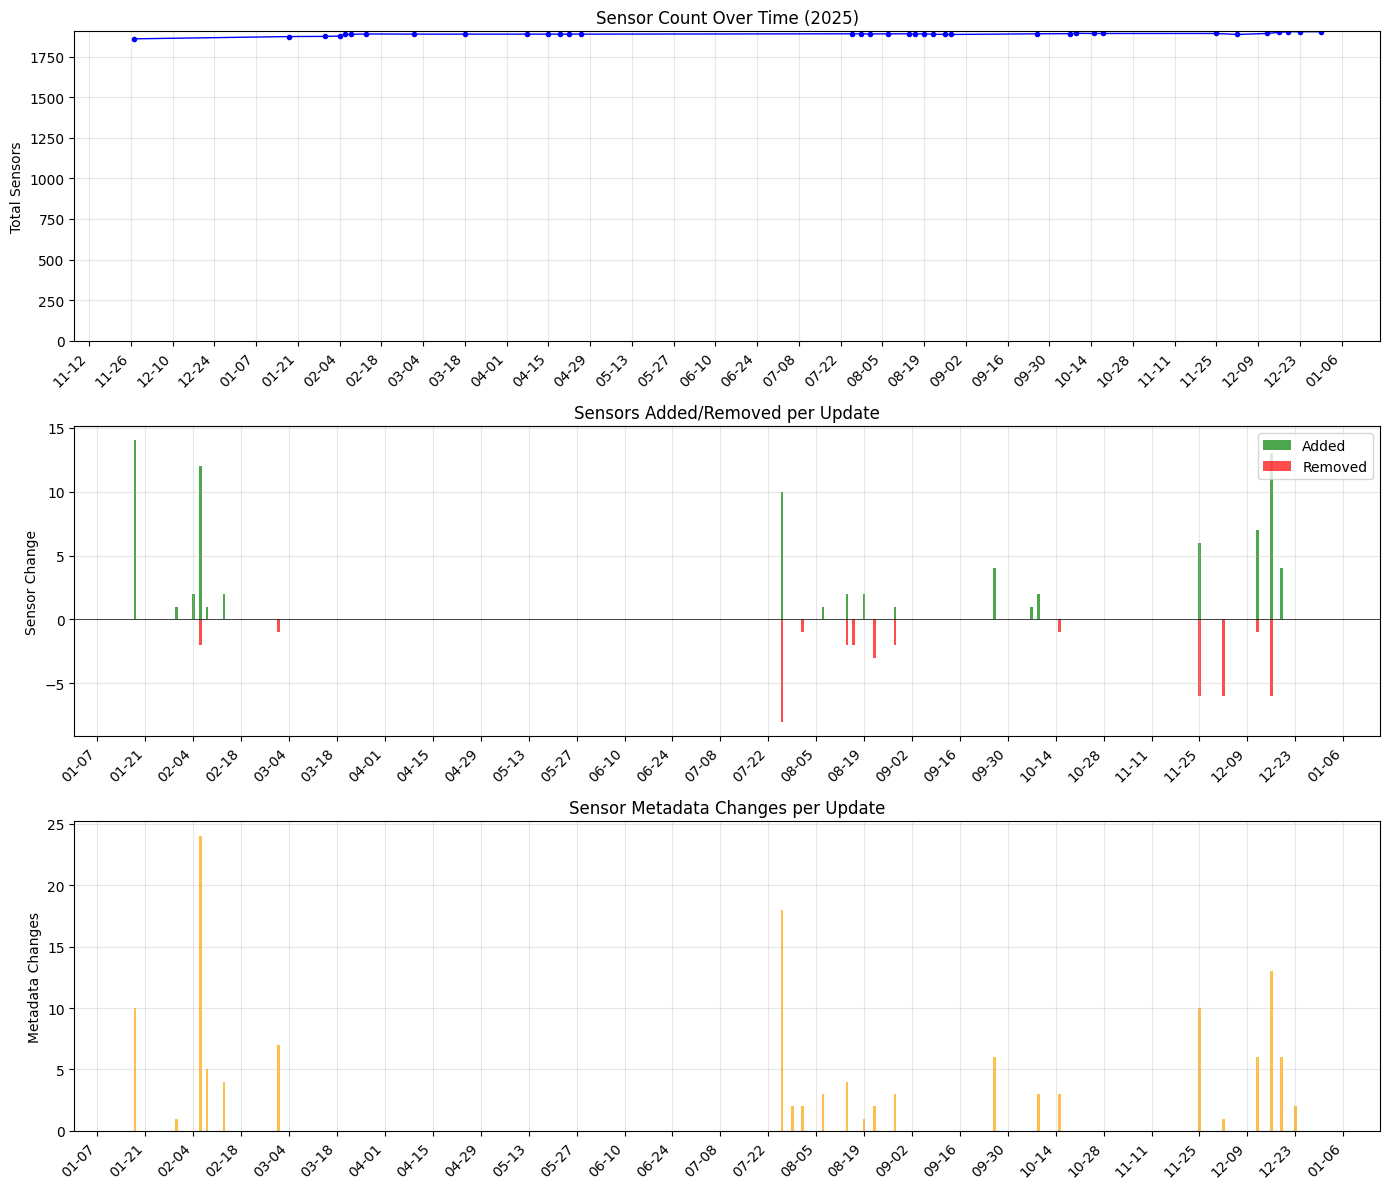

图表已保存: sensor_changes_2025.png


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 图1: 传感器总数变化
axes[0].plot(changes_df['Date'], changes_df['Total'], 'b-o', markersize=3, linewidth=1)
axes[0].set_ylabel('Total Sensors')
axes[0].set_title('Sensor Count Over Time (2025)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# 图2: 新增/移除传感器（排除第一个时间点）
plot_df = changes_df[~changes_df['Is_First']].copy()
if len(plot_df) > 0:
    axes[1].bar(plot_df['Date'], plot_df['Added'], color='green', alpha=0.7, label='Added', width=0.8)
    axes[1].bar(plot_df['Date'], -plot_df['Removed'], color='red', alpha=0.7, label='Removed', width=0.8)
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].set_ylabel('Sensor Change')
    axes[1].set_title('Sensors Added/Removed per Update')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

# 图3: 元数据变化
if len(plot_df) > 0:
    axes[2].bar(plot_df['Date'], plot_df['Metadata_Changed'], color='orange', alpha=0.7, width=0.8)
    axes[2].set_ylabel('Metadata Changes')
    axes[2].set_title('Sensor Metadata Changes per Update')
    axes[2].grid(True, alpha=0.3)

# 格式化x轴
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sensor_changes_2025.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"图表已保存: sensor_changes_2025.png")

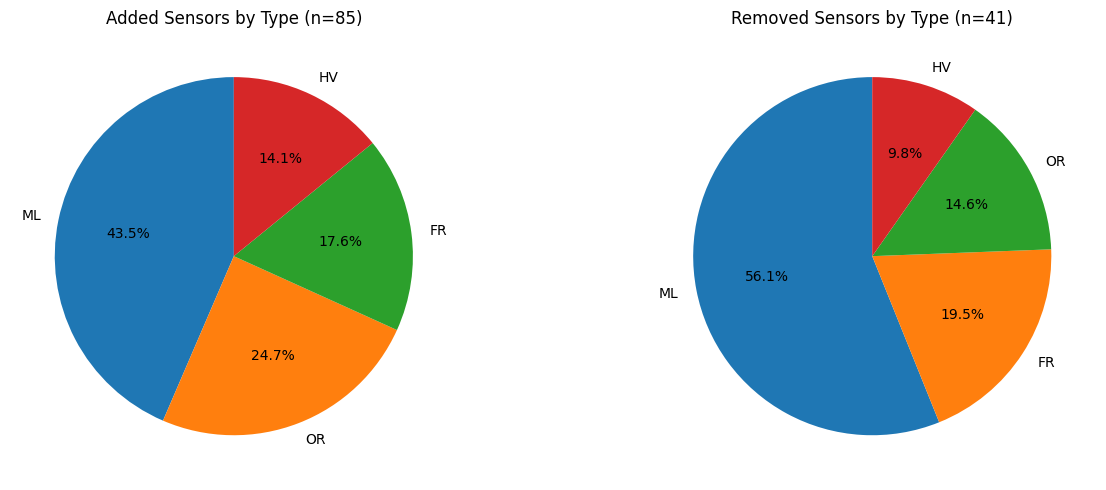

图表已保存: sensor_changes_by_type.png


In [14]:
# 按传感器类型分析变化
if len(added_df) > 0 or len(removed_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 新增传感器类型分布
    if len(added_df) > 0:
        added_by_type = added_df['Type'].value_counts()
        axes[0].pie(added_by_type.values, labels=added_by_type.index, autopct='%1.1f%%', startangle=90)
        axes[0].set_title(f'Added Sensors by Type (n={len(added_df)})')
    else:
        axes[0].text(0.5, 0.5, 'No Added Sensors', ha='center', va='center')
        axes[0].set_title('Added Sensors by Type')
    
    # 移除传感器类型分布
    if len(removed_df) > 0:
        removed_by_type = removed_df['Type'].value_counts()
        axes[1].pie(removed_by_type.values, labels=removed_by_type.index, autopct='%1.1f%%', startangle=90)
        axes[1].set_title(f'Removed Sensors by Type (n={len(removed_df)})')
    else:
        axes[1].text(0.5, 0.5, 'No Removed Sensors', ha='center', va='center')
        axes[1].set_title('Removed Sensors by Type')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sensor_changes_by_type.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"图表已保存: sensor_changes_by_type.png")

## 9. 车道级分析

In [15]:
# 加载最新的元数据进行车道级分析
latest_file, latest_date = files_in_range[-1]
latest_df = load_metadata(latest_file)

print(f"最新元数据日期: {latest_date.date()}")
print(f"传感器总数: {len(latest_df)}")
print()

# 按类型统计
print("按类型统计:")
type_stats = latest_df.groupby('Type').agg({
    'ID': 'count',
    'Lanes': ['sum', 'mean']
}).round(2)
type_stats.columns = ['Sensor_Count', 'Total_Lanes', 'Avg_Lanes']
display(type_stats)

最新元数据日期: 2025-12-30
传感器总数: 1903

按类型统计:


,Sensor_Count,Total_Lanes,Avg_Lanes
Type,,,
FF,28,51,1.82
FR,279,402,1.44
HV,281,281,1.00
ML,884,2394,2.71
OR,431,585,1.36


In [16]:
# 检测同位置多传感器（HOV vs 主线）
def find_colocated_sensors(df, pm_threshold=0.01):
    """
    找出同位置的传感器对（Fwy + Dir + Abs_PM 相同）
    """
    colocated = []
    
    for (fwy, direction), group in df.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        i = 0
        while i < len(sorted_group):
            current_pm = sorted_group.iloc[i]['Abs_PM']
            
            # 找出同位置的所有传感器
            same_loc = sorted_group[
                abs(sorted_group['Abs_PM'] - current_pm) < pm_threshold
            ]
            
            if len(same_loc) > 1:
                colocated.append({
                    'Fwy': fwy,
                    'Dir': direction,
                    'Abs_PM': current_pm,
                    'Sensor_Count': len(same_loc),
                    'IDs': same_loc['ID'].tolist(),
                    'Types': same_loc['Type'].tolist(),
                    'Lanes': same_loc['Lanes'].tolist(),
                    'Total_Lanes': same_loc['Lanes'].sum()
                })
            
            i += len(same_loc)
    
    return pd.DataFrame(colocated)


colocated_df = find_colocated_sensors(latest_df)
print(f"同位置多传感器组数: {len(colocated_df)}")

if len(colocated_df) > 0:
    print("\n同位置传感器示例:")
    display(colocated_df.head(10))

同位置多传感器组数: 422

同位置传感器示例:


,Fwy,Dir,Abs_PM,Sensor_Count,IDs,Types,Lanes,Total_Lanes
0,113,N,32.297,3,"[316484, 316483, 316482]","[FR, OR, ML]","[2, 1, 2]",5
1,113,S,31.918,2,"[3034035, 3034036]","[OR, FR]","[2, 1]",3
2,12,E,69.266,2,"[3102022, 3102024]","[ML, ML]","[1, 1]",2
3,12,W,69.235,2,"[3102021, 3102041]","[ML, ML]","[1, 1]",2
4,160,N,48.588,3,"[314521, 314576, 314575]","[ML, FR, OR]","[2, 1, 2]",5
5,160,S,48.588,2,"[314580, 316493]","[ML, FR]","[2, 1]",3
6,193,E,10.071,2,"[3038098, 3038095]","[FR, OR]","[1, 2]",3
7,20,E,183.792,5,"[3422045, 3422044, 3422043, 3422042, 3422041]","[FR, FR, OR, OR, ML]","[1, 2, 1, 1, 2]",7
8,20,E,185.058,2,"[3422056, 3422055]","[OR, OR]","[1, 1]",2
9,20,W,185.117,2,"[3422092, 3422059]","[ML, FR]","[3, 3]",6


In [17]:
# 分析同位置传感器的车道配置
if len(colocated_df) > 0:
    print("同位置传感器的车道配置分析:")
    
    # 最常见的车道组合
    lanes_combos = colocated_df['Lanes'].apply(lambda x: tuple(sorted(x)))
    print("\n最常见的车道组合:")
    print(lanes_combos.value_counts().head(10))
    
    # 总车道数分布
    print("\n合并后的总车道数分布:")
    print(colocated_df['Total_Lanes'].value_counts().sort_index())

同位置传感器的车道配置分析:

最常见的车道组合:
Lanes
(1, 2)       60
(1, 3)       46
(1, 1)       36
(1, 4)       35
(2, 2)       21
(1, 1, 2)    18
(2, 3)       17
(1, 2, 4)    16
(1, 1, 3)    15
(2, 4)       13
Name: count, dtype: int64

合并后的总车道数分布:
Total_Lanes
2     36
3     63
4     86
5     81
6     67
7     46
8     21
9     10
10     5
11     4
13     1
14     1
16     1
Name: count, dtype: int64


## 10. 保存结果

In [18]:
# 保存汇总统计
changes_df.to_csv(os.path.join(OUTPUT_DIR, 'sensor_changes_summary.csv'), index=False)
print(f"已保存: sensor_changes_summary.csv")

# 保存新增传感器详情
if len(added_df) > 0:
    added_df.to_csv(os.path.join(OUTPUT_DIR, 'sensors_added.csv'), index=False)
    print(f"已保存: sensors_added.csv")

# 保存移除传感器详情
if len(removed_df) > 0:
    removed_df.to_csv(os.path.join(OUTPUT_DIR, 'sensors_removed.csv'), index=False)
    print(f"已保存: sensors_removed.csv")

# 保存元数据变化详情
if len(metadata_changes_df) > 0:
    metadata_changes_df.to_csv(os.path.join(OUTPUT_DIR, 'metadata_changes.csv'), index=False)
    print(f"已保存: metadata_changes.csv")

# 保存同位置传感器分析
if len(colocated_df) > 0:
    colocated_df.to_csv(os.path.join(OUTPUT_DIR, 'colocated_sensors.csv'), index=False)
    print(f"已保存: colocated_sensors.csv")

print("\n所有结果已保存！")

已保存: sensor_changes_summary.csv
已保存: sensors_added.csv
已保存: sensors_removed.csv
已保存: metadata_changes.csv
已保存: colocated_sensors.csv

所有结果已保存！


---
## 输出文件说明

| 文件 | 说明 |
|------|------|
| `sensor_changes_summary.csv` | 每个时间点的变化汇总 |
| `sensors_added.csv` | 新增传感器详情 |
| `sensors_removed.csv` | 移除传感器详情 |
| `metadata_changes.csv` | 元数据变化详情 |
| `colocated_sensors.csv` | 同位置多传感器分析 |
| `sensor_changes_2025.png` | 变化趋势图 |
| `sensor_changes_by_type.png` | 按类型统计图 |

## 关键发现

1. **第一个时间点**：作为基准，新增/移除均为 0
2. **同位置传感器**：HOV 和主线车道在同一里程位置有独立传感器
3. **元数据变化**：追踪车道数、位置、类型等字段的变更